In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
primary = "#2563EB"
secondary = "#3B82F6"
accent = "#60A5FA"
background = "#F8FAFC"
text_color = "#1E293B"

In [3]:
df = pd.read_csv("/content/drive/MyDrive/data/cleaned_data_UK.csv")

df["Date of Purchase"] = pd.to_datetime(df["Date of Purchase"])
daily_sales = df.groupby("Date of Purchase")["Price"].sum().reset_index()
daily_sales.columns = ["date", "sales"]

daily_sales["day_num"] = np.arange(len(daily_sales))
daily_sales["day_of_week"] = daily_sales["date"].dt.dayofweek
daily_sales["month"] = daily_sales["date"].dt.month
daily_sales["day_of_month"] = daily_sales["date"].dt.day
daily_sales["rolling_7"] = daily_sales["sales"].rolling(7, min_periods=1).mean()
daily_sales["rolling_14"] = daily_sales["sales"].rolling(14, min_periods=1).mean()
daily_sales["lag_1"] = daily_sales["sales"].shift(1).fillna(daily_sales["sales"].mean())
daily_sales["lag_7"] = daily_sales["sales"].shift(7).fillna(daily_sales["sales"].mean())


In [4]:
train = daily_sales.iloc[:-10]
test = daily_sales.iloc[-10:]
features = ["day_num", "day_of_week", "month", "day_of_month", "rolling_7", "rolling_14", "lag_1", "lag_7"]
X_train, y_train = train[features], train["sales"]
X_test, y_test = test[features], test["sales"]

rf = RandomForestRegressor(n_estimators=300, random_state=42)
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

ensemble_train = np.column_stack([rf.predict(X_train), xgb.predict(X_train)])
meta_model = LinearRegression()
meta_model.fit(ensemble_train, y_train)

ensemble_test = np.column_stack([rf.predict(X_test), xgb.predict(X_test)])
final_pred = meta_model.predict(ensemble_test)

In [6]:
future_days = np.arange(len(daily_sales), len(daily_sales) + 60)
future_dates = pd.date_range(daily_sales["date"].max(), periods=60, freq="D")

future_df = pd.DataFrame({
    "date": future_dates,
    "day_num": future_days,
})
future_df["day_of_week"] = future_df["date"].dt.dayofweek
future_df["month"] = future_df["date"].dt.month
future_df["day_of_month"] = future_df["date"].dt.day
future_df["rolling_7"] = daily_sales["sales"].iloc[-7:].mean()
future_df["rolling_14"] = daily_sales["sales"].iloc[-14:].mean()
future_df["lag_1"] = daily_sales["sales"].iloc[-1]
future_df["lag_7"] = daily_sales["sales"].iloc[-7]

rf_future = rf.predict(future_df[features])
xgb_future = xgb.predict(future_df[features])
ensemble_future = np.column_stack([rf_future, xgb_future])
future_df["predicted_sales"] = meta_model.predict(ensemble_future)

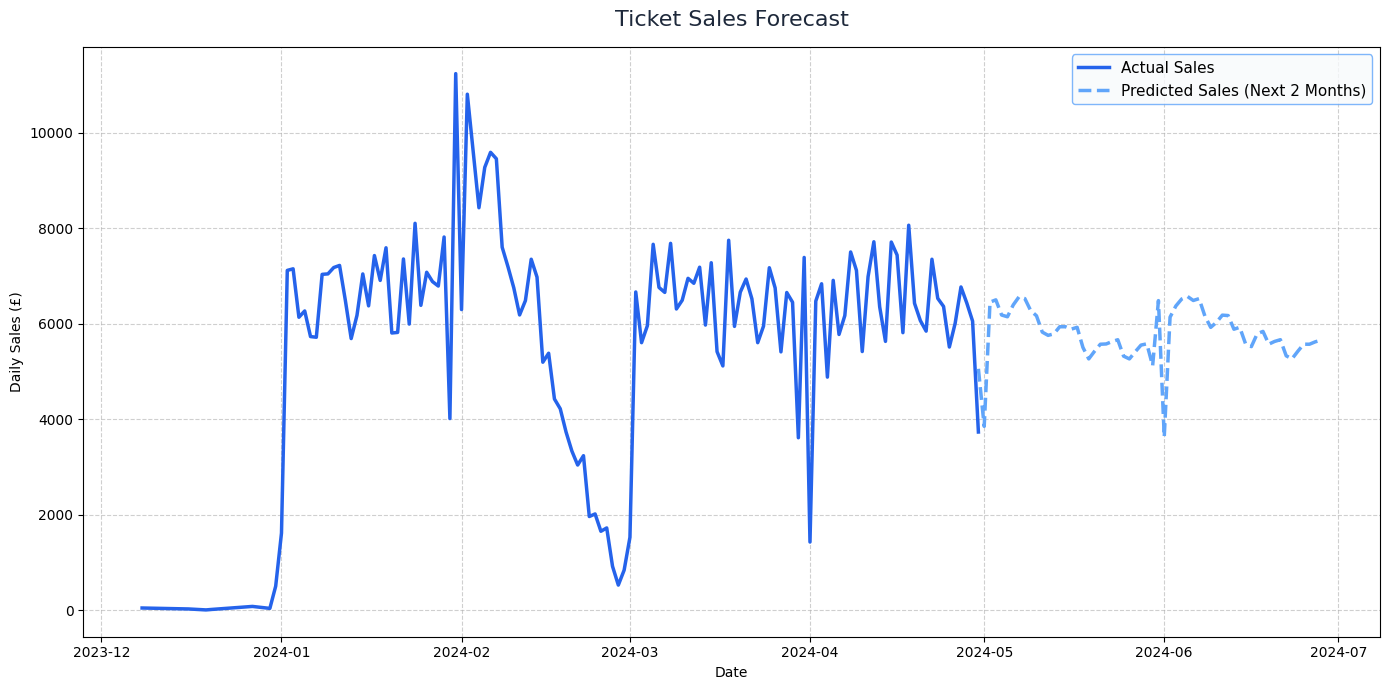

In [8]:
plt.figure(figsize=(14,7))
plt.plot(daily_sales["date"], daily_sales["sales"], label="Actual Sales", color=primary, linewidth=2.5)
plt.plot(future_df["date"], future_df["predicted_sales"], "--", label="Predicted Sales (Next 2 Months)", color=accent, linewidth=2.5)
plt.title("Ticket Sales Forecast", fontsize=16, color=text_color, pad=15)
plt.xlabel("Date")
plt.ylabel("Daily Sales (£)")
plt.legend(facecolor=background, edgecolor=accent, fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()